In [ ]:
import sys
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import os
import numpy as np
import random
from torch.utils.data import TensorDataset
sys.path.append("/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST")
import torch.nn.functional as F
from cvae_model import CVAE, cvae_loss
from torch.utils.data import Subset

sample_size = 5000 # real data number
filter_threshold = 0.5 # p=0.5

# One-hot encoding helper
def one_hot(labels, num_classes=10):
    return F.one_hot(labels, num_classes).float()

def generate_images_in_batches(model, total_samples, latent_dim, num_classes, batch_size=10000, device='cuda'):
    model.eval()
    generated_images = []
    all_labels = []

    for start in range(0, total_samples, batch_size):
        end = min(start + batch_size, total_samples)
        batch_size_actual = end - start

        # Generate z and y
        z = torch.randn(batch_size_actual, latent_dim).to(device)
        y = torch.arange(num_classes).repeat_interleave(total_samples // num_classes)[start:end]
        y_onehot = F.one_hot(y, num_classes=num_classes).float().to(device)

        with torch.no_grad():
            imgs = model.decode(z, y_onehot).view(-1, 1, 28, 28).cpu()
            generated_images.append(imgs)
            all_labels.append(y)

    images = torch.cat(generated_images, dim=0)
    labels = torch.cat(all_labels, dim=0)
    return images, labels

############################ real data training ############################
seed = 0
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
random.seed(seed)

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Hyperparameters
latent_dim = 20
label_dim = 10
batch_size = 128
epochs = 200
lr = 1e-3
patience = 5

# Load MNIST
transform = transforms.ToTensor()
full_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
train_dataset = Subset(full_dataset, range(sample_size))
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Initialize model
model = CVAE(latent_dim=latent_dim, label_dim=label_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

best_train_loss = float('inf')
trigger_times = 0

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for x, y in train_loader:
        x = x.view(-1, 784).to(device)
        y = one_hot(y).to(device)

        optimizer.zero_grad()
        recon_x, mu, logvar = model(x, y)
        loss = cvae_loss(recon_x, x, mu, logvar)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader.dataset)
    print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {avg_loss:.4f}")

    # Early stopping based on training loss
    if avg_loss < best_train_loss:
        best_train_loss = avg_loss
        trigger_times = 0
    else:
        trigger_times += 1
        print(f"EarlyStopping counter: {trigger_times} out of {patience}")
        if trigger_times >= patience:
            print("Early stopping triggered.")
            break
os.chdir("/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST")  
# save the model to model_saved folder
torch.save(model.state_dict(), f"model_saved/cvae_mnist_{sample_size}.pth")
print(f"Model saved to model_saved/cvae_mnist_{sample_size}.pth")

model0_path = f"/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/model_saved/cvae_mnist_{sample_size}.pth"
############################ generate synthetic data ############################

model = CVAE(latent_dim=latent_dim, label_dim=label_dim)
model.load_state_dict(torch.load(f"model_saved/cvae_mnist_{sample_size}.pth"))
model.eval()

# large sample size for training
latent_dim = model.latent_dim
device = next(model.parameters()).device
gen_imgs_before_filter,y_before_filter = generate_images_in_batches(
    model=model,
    total_samples=6000000,
    latent_dim=latent_dim,
    num_classes=10,
    batch_size=10000,
    device=device
)

# large sample size for training
latent_dim = model.latent_dim
device = next(model.parameters()).device
gen_imgs_for_synthetic_training,y_for_synthetic_training = generate_images_in_batches(
    model=model,
    total_samples=50000,
    latent_dim=latent_dim,
    num_classes=10,
    batch_size=10000,
    device=device
)
########################## train model using unfiltered synthetic data ##########################
images = gen_imgs_for_synthetic_training  # shape: [N, 1, 28, 28]
labels = y_for_synthetic_training # shape: [N]

print(f"Loaded {images.shape[0]} unfiltered synthetic samples")

# Preprocess: flatten images and convert labels to one-hot
images = images.view(-1, 784)  # flatten to [N, 784]

# Create dataset and dataloader
dataset = TensorDataset(images, labels)
train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Initialize model
model = CVAE(latent_dim=latent_dim, label_dim=label_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

best_train_loss = float('inf')
for epoch in range(epochs):
    model.train()
    total_loss = 0

    for x, y in train_loader:
        x = x.view(-1, 784).to(device)
        y = one_hot(y).to(device)

        optimizer.zero_grad()
        recon_x, mu, logvar = model(x, y)
        loss = cvae_loss(recon_x, x, mu, logvar)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader.dataset)
    print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {avg_loss:.4f}")

    # Early stopping based on training loss
    if avg_loss < best_train_loss:
        best_train_loss = avg_loss
        trigger_times = 0
    else:
        trigger_times += 1
        print(f"EarlyStopping counter: {trigger_times} out of {patience}")
        if trigger_times >= patience:
            print("Early stopping triggered.")
            break

# save the model to model_saved folder
torch.save(model.state_dict(), f"model_saved/cvae_mnist_unfiltered_synthetic_data_{sample_size}.pth")
model00_path = f"model_saved/cvae_mnist_unfiltered_synthetic_data_{sample_size}.pth"

############################ filter synthetic data ############################

from discriminator import Discriminator
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
D = Discriminator().to(device)
D.load_state_dict(torch.load("model_saved/discriminator_mnist_cvae_2.pth"))
D.eval()

#data = torch.load(f"data_saved/synthetic_mnist_cvae_{sample_size}.pt")
#synthetic_images = data['images']  

synthetic_loader = DataLoader(gen_imgs_before_filter, batch_size=512)

all_probs = []

with torch.no_grad():
    for batch in synthetic_loader:
        batch = batch.to(device)
        probs = D(batch)  # [batch_size, 1], already sigmoid activated
        all_probs.append(probs.cpu())

all_probs = torch.cat(all_probs, dim=0)
# Flatten probs to shape [N]
probs = all_probs.squeeze(1)

# Load images and labels
images = gen_imgs_before_filter#data['images']      # [N, 1, 28, 28]
labels = y_before_filter #data['labels']      # [N]
# Create mask for p > filter_threshold
mask = probs > filter_threshold

# Apply mask
filtered_images = images[mask]
filtered_labels = labels[mask]

print(f"Selected {filtered_images.shape[0]} samples with p > {filter_threshold}")
# Save to file
torch.save({
    'images': filtered_images,
    'labels': filtered_labels
}, f"data_saved/synthetic_mnist_filtered_pgt{filter_threshold}_{sample_size}.pt")


############################ synthetic data retraining ############################

images = filtered_images  # shape: [N, 1, 28, 28]
labels = filtered_labels  # shape: [N]

print(f"Loaded {images.shape[0]} filtered synthetic samples")

# Preprocess: flatten images and convert labels to one-hot
images = images.view(-1, 784)  # flatten to [N, 784]

# Create dataset and dataloader
dataset = TensorDataset(images, labels)
train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Initialize model
model = CVAE(latent_dim=latent_dim, label_dim=label_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

best_train_loss = float('inf')
for epoch in range(epochs):
    model.train()
    total_loss = 0

    for x, y in train_loader:
        x = x.view(-1, 784).to(device)
        y = one_hot(y).to(device)

        optimizer.zero_grad()
        recon_x, mu, logvar = model(x, y)
        loss = cvae_loss(recon_x, x, mu, logvar)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader.dataset)
    print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {avg_loss:.4f}")

    # Early stopping based on training loss
    if avg_loss < best_train_loss:
        best_train_loss = avg_loss
        trigger_times = 0
    else:
        trigger_times += 1
        print(f"EarlyStopping counter: {trigger_times} out of {patience}")
        if trigger_times >= patience:
            print("Early stopping triggered.")
            break

# save the model to model_saved folder
torch.save(model.state_dict(), f"model_saved/cvae_mnist_filtered_synthetic_data_{sample_size}.pth")
model1_path = f"model_saved/cvae_mnist_filtered_synthetic_data_{sample_size}.pth"

Epoch [1/200], Train Loss: 289.2108
Epoch [2/200], Train Loss: 203.2987
Epoch [3/200], Train Loss: 180.5909
Epoch [4/200], Train Loss: 163.6566
Epoch [5/200], Train Loss: 153.5960
Epoch [6/200], Train Loss: 147.1927
Epoch [7/200], Train Loss: 142.1991
Epoch [8/200], Train Loss: 138.1548
Epoch [9/200], Train Loss: 135.0436
Epoch [10/200], Train Loss: 131.6576
Epoch [11/200], Train Loss: 128.9200
Epoch [12/200], Train Loss: 126.7012
Epoch [13/200], Train Loss: 124.4985
Epoch [14/200], Train Loss: 122.8120
Epoch [15/200], Train Loss: 121.3929
Epoch [16/200], Train Loss: 120.2515
Epoch [17/200], Train Loss: 119.0146
Epoch [18/200], Train Loss: 117.9805
Epoch [19/200], Train Loss: 116.8355
Epoch [20/200], Train Loss: 115.8772
Epoch [21/200], Train Loss: 115.1748
Epoch [22/200], Train Loss: 114.4071
Epoch [23/200], Train Loss: 113.7253
Epoch [24/200], Train Loss: 112.9484
Epoch [25/200], Train Loss: 112.5313
Epoch [26/200], Train Loss: 111.9499
Epoch [27/200], Train Loss: 111.3571
Epoch [28/

/tmp/ipykernel_1119740/346945593.py:115: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"model_saved/cvae_mnist_{sample_size}.pth"))


Loaded 50000 unfiltered synthetic samples
Epoch [1/200], Train Loss: 170.4608
Epoch [2/200], Train Loss: 134.1210
Epoch [3/200], Train Loss: 128.3349
Epoch [4/200], Train Loss: 125.6928
Epoch [5/200], Train Loss: 124.1731
Epoch [6/200], Train Loss: 123.1891
Epoch [7/200], Train Loss: 122.4477
Epoch [8/200], Train Loss: 121.9633
Epoch [9/200], Train Loss: 121.5954
Epoch [10/200], Train Loss: 121.3115
Epoch [11/200], Train Loss: 121.0394
Epoch [12/200], Train Loss: 120.8376
Epoch [13/200], Train Loss: 120.6844
Epoch [14/200], Train Loss: 120.5761
Epoch [15/200], Train Loss: 120.4468
Epoch [16/200], Train Loss: 120.3146
Epoch [17/200], Train Loss: 120.2824
Epoch [18/200], Train Loss: 120.1990
Epoch [19/200], Train Loss: 120.1141
Epoch [20/200], Train Loss: 120.0512
Epoch [21/200], Train Loss: 119.9640
Epoch [22/200], Train Loss: 119.9606
Epoch [23/200], Train Loss: 119.8805
Epoch [24/200], Train Loss: 119.8420
Epoch [25/200], Train Loss: 119.7777
Epoch [26/200], Train Loss: 119.7744
Epoch

/tmp/ipykernel_1119740/346945593.py:198: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  D.load_state_dict(torch.load("model_saved/discriminator_mnist_cvae_2.pth"))


Selected 87540 samples with p > 0.5
Loaded 87540 filtered synthetic samples
Epoch [1/200], Train Loss: 134.0207
Epoch [2/200], Train Loss: 102.7283
Epoch [3/200], Train Loss: 98.3413
Epoch [4/200], Train Loss: 96.3478
Epoch [5/200], Train Loss: 95.1937
Epoch [6/200], Train Loss: 94.4107
Epoch [7/200], Train Loss: 93.9125
Epoch [8/200], Train Loss: 93.4757
Epoch [9/200], Train Loss: 93.2312
Epoch [10/200], Train Loss: 92.9705
Epoch [11/200], Train Loss: 92.7719
Epoch [12/200], Train Loss: 92.6556
Epoch [13/200], Train Loss: 92.5071
Epoch [14/200], Train Loss: 92.4034
Epoch [15/200], Train Loss: 92.2981
Epoch [16/200], Train Loss: 92.2230
Epoch [17/200], Train Loss: 92.1640
Epoch [18/200], Train Loss: 92.0245
Epoch [19/200], Train Loss: 91.9975
Epoch [20/200], Train Loss: 91.9304
Epoch [21/200], Train Loss: 91.8850
Epoch [22/200], Train Loss: 91.8408
Epoch [23/200], Train Loss: 91.7841
Epoch [24/200], Train Loss: 91.7634
Epoch [25/200], Train Loss: 91.7075
Epoch [26/200], Train Loss: 91.

# Evaluate

## visualize

In [2]:
model1_path = f"/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/model_saved/cvae_mnist_filtered_synthetic_data_{sample_size}.pth"
model0_path = f"/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/model_saved/cvae_mnist_{sample_size}.pth"
model00_path = f"/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/model_saved/cvae_mnist_unfiltered_synthetic_data_{sample_size}.pth"

In [5]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Hyperparameters
latent_dim = 20
label_dim = 10
batch_size = 128
epochs = 200
lr = 1e-3
patience = 5

/tmp/ipykernel_1880220/3546602697.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model1.load_state_dict(torch.load(model1_path, map_location=device))
/tmp/ipykernel_188

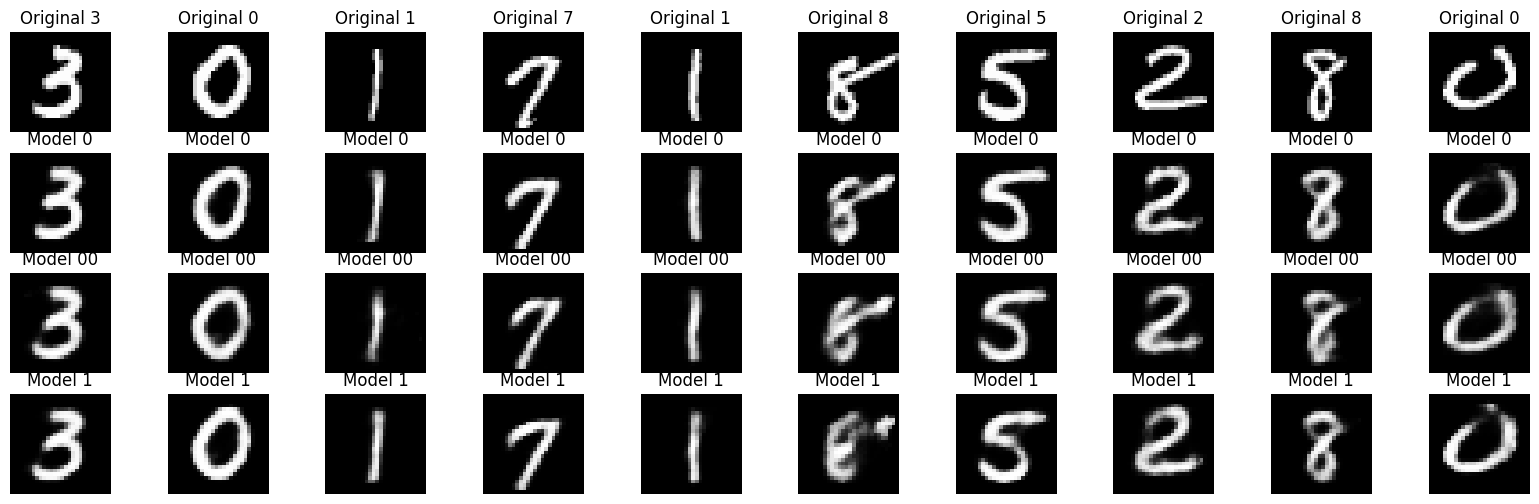

In [6]:
# reconstruct some test data and show the result
model1 = CVAE(latent_dim=latent_dim, label_dim=label_dim).to(device)

model1.load_state_dict(torch.load(model1_path, map_location=device))
model1.eval()

model0 = CVAE(latent_dim=latent_dim, label_dim=label_dim).to(device)
model0.load_state_dict(torch.load(model0_path, map_location=device))
model0.eval()

model00 = CVAE(latent_dim=latent_dim, label_dim=label_dim).to(device)
model00.load_state_dict(torch.load(model00_path, map_location=device))
model00.eval()

# Get some test data
test_dataset = datasets.MNIST(root="./data", train=False, transform=transforms.ToTensor())
test_loader = DataLoader(test_dataset, batch_size=10, shuffle=True) # batch size 10 to get 10 samples
data_iter = iter(test_loader)
test_images, test_labels = next(data_iter)
test_images = test_images.view(-1, 784).to(device)  # flatten   to [10, 784]
test_labels_onehot = F.one_hot(test_labels, num_classes=10).float().to(device)  # to one-hot    to [10, 10]     
with torch.no_grad():
    recon_images0, _, _ = model0(test_images, test_labels_onehot)
    recon_images1, _, _ = model1(test_images, test_labels_onehot)
    recon_images00, _, _ = model00(test_images, test_labels_onehot)
recon_images0 = recon_images0.view(-1, 1, 28, 28).cpu()
recon_images1 = recon_images1.view(-1, 1, 28, 28).cpu()
recon_images00 = recon_images00.view(-1, 1, 28, 28).cpu()
test_images = test_images.view(-1, 1, 28, 28).cpu() # reshape back to [10, 1, 28, 28]

# Plot original and reconstructed images side by side
fig, axes = plt.subplots(4, 10, figsize=(20, 6))
for i in range(10):
    axes[0, i].imshow(test_images[i].squeeze(), cmap='gray')
    axes[0, i].set_title(f'Original {test_labels[i].item()}')
    axes[0, i].axis('off')
    
    axes[1, i].imshow(recon_images0[i].squeeze(), cmap='gray')
    axes[1, i].set_title('Model 0')
    axes[1, i].axis('off')

    axes[2, i].imshow(recon_images00[i].squeeze(), cmap='gray')
    axes[2, i].set_title('Model 00')
    axes[2, i].axis('off')

    axes[3, i].imshow(recon_images1[i].squeeze(), cmap='gray')
    axes[3, i].set_title('Model 1')
    axes[3, i].axis('off')

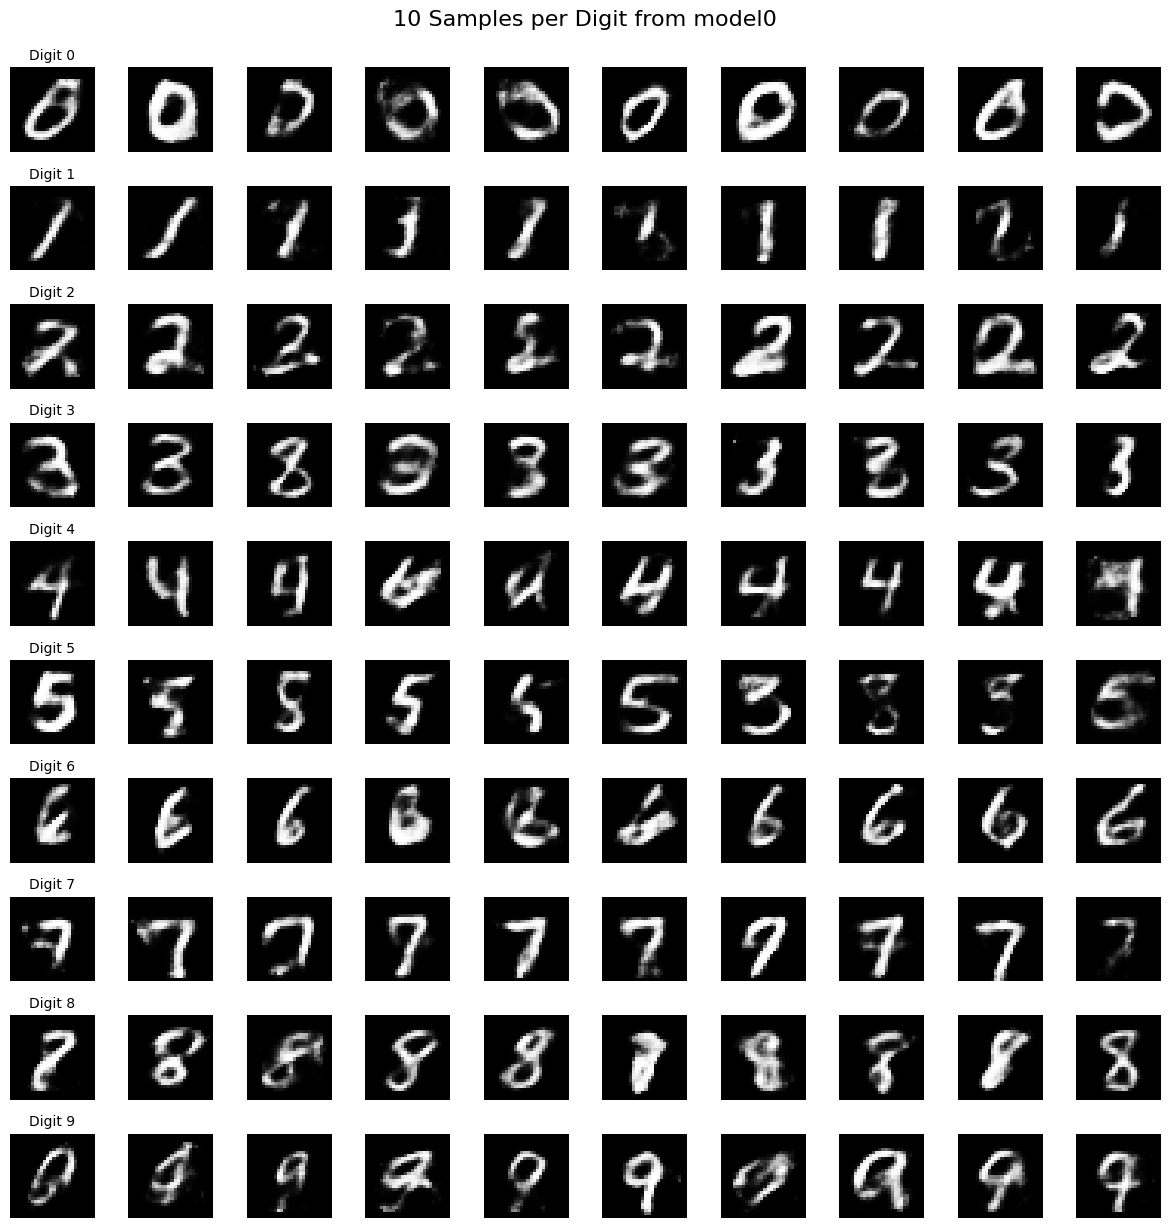

In [9]:
model=model0
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
synthetic_gen_size = 6000
gen_imgs_before_filter,y_before_filter = generate_images_in_batches(
    model=model0,
    total_samples=synthetic_gen_size,
    latent_dim=latent_dim,
    num_classes=10,
    batch_size=10000,
    device=device
)
# Load synthetic data
#synthetic = torch.load(f"data_saved/synthetic_mnist_cvae_{sample_size}_2.pt")
images = gen_imgs_before_filter # [N, 1, 28, 28]
labels = y_before_filter  # [N]

# Ensure on CPU for plotting
images = images.cpu()
labels = labels.cpu()

# Plot 10 samples for each digit
fig, axes = plt.subplots(10, 10, figsize=(12, 12))

for digit in range(10):
    digit_indices = (labels == digit).nonzero(as_tuple=True)[0]
    selected_indices = digit_indices[:10]  # take first 10

    for i, idx in enumerate(selected_indices):
        ax = axes[digit, i]
        ax.imshow(images[idx].squeeze(), cmap="gray")
        ax.axis("off")
        if i == 0:
            ax.set_title(f"Digit {digit}", fontsize=10)

plt.tight_layout()
plt.suptitle("10 Samples per Digit from model0", y=1.02, fontsize=16)
plt.show()


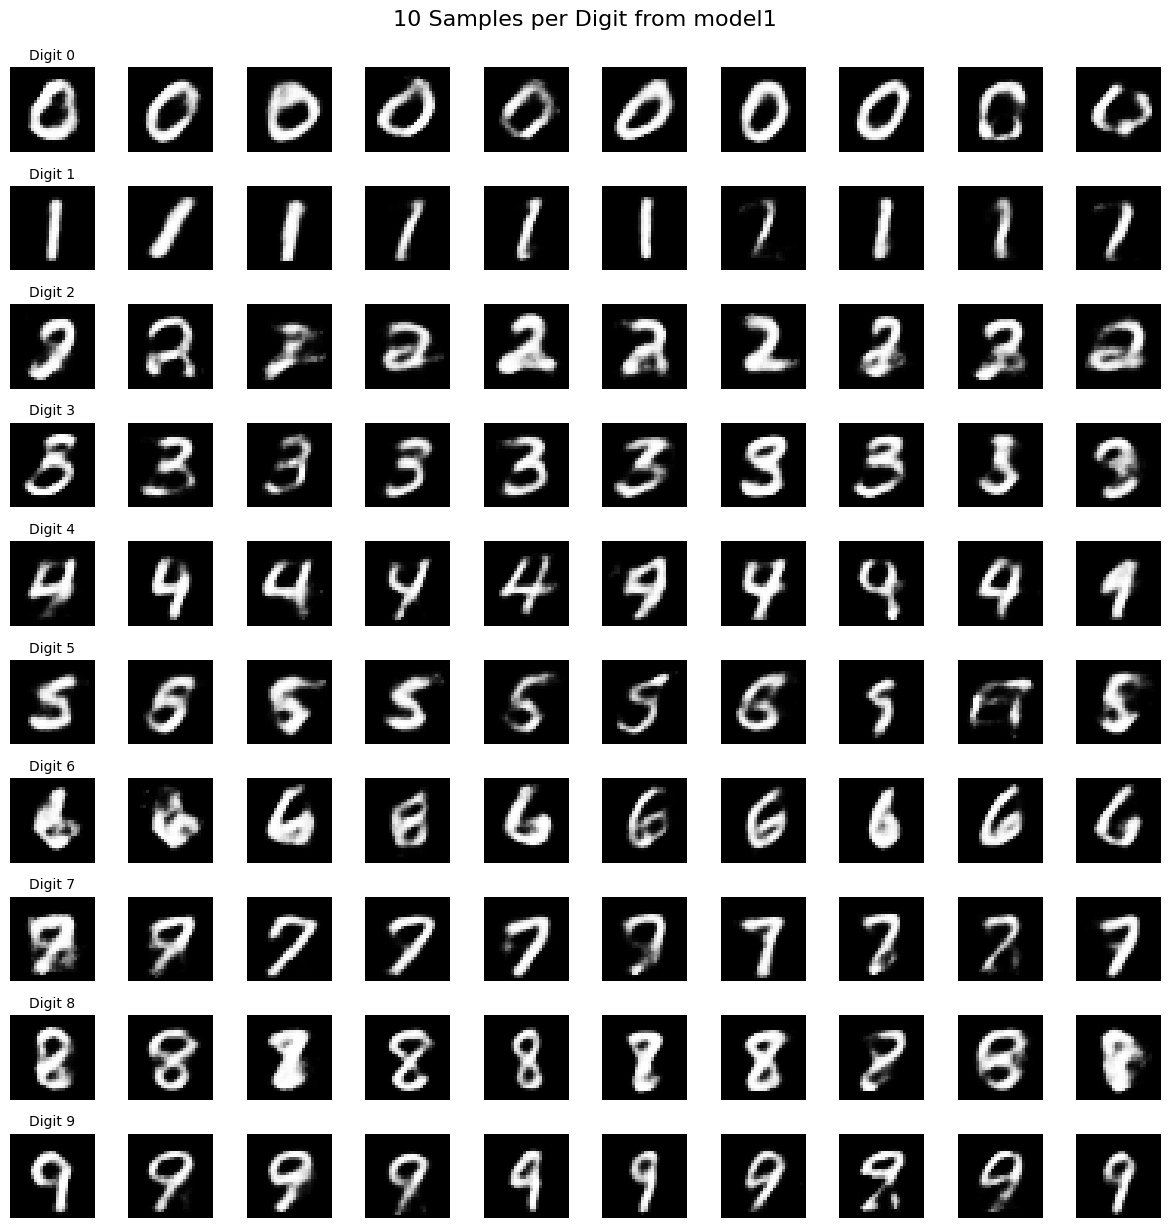

In [11]:
model=model1
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
# large sample size for training


synthetic_gen_size = 6000
# large sample size for training

gen_imgs_before_filter,y_before_filter = generate_images_in_batches(
    model=model1,
    total_samples=synthetic_gen_size,
    latent_dim=latent_dim,
    num_classes=10,
    batch_size=10000,
    device=device
)
# Load synthetic data
#synthetic = torch.load(f"data_saved/synthetic_mnist_cvae_{sample_size}_2.pt")
images = gen_imgs_before_filter # [N, 1, 28, 28]
labels = y_before_filter  # [N]

# Ensure on CPU for plotting
images = images.cpu()
labels = labels.cpu()

# Plot 10 samples for each digit
fig, axes = plt.subplots(10, 10, figsize=(12, 12))

for digit in range(10):
    digit_indices = (labels == digit).nonzero(as_tuple=True)[0]
    selected_indices = digit_indices[:10]  # take first 10

    for i, idx in enumerate(selected_indices):
        ax = axes[digit, i]
        ax.imshow(images[idx].squeeze(), cmap="gray")
        ax.axis("off")
        if i == 0:
            ax.set_title(f"Digit {digit}", fontsize=10)

plt.tight_layout()
plt.suptitle("10 Samples per Digit from model1", y=1.02, fontsize=16)
plt.show()

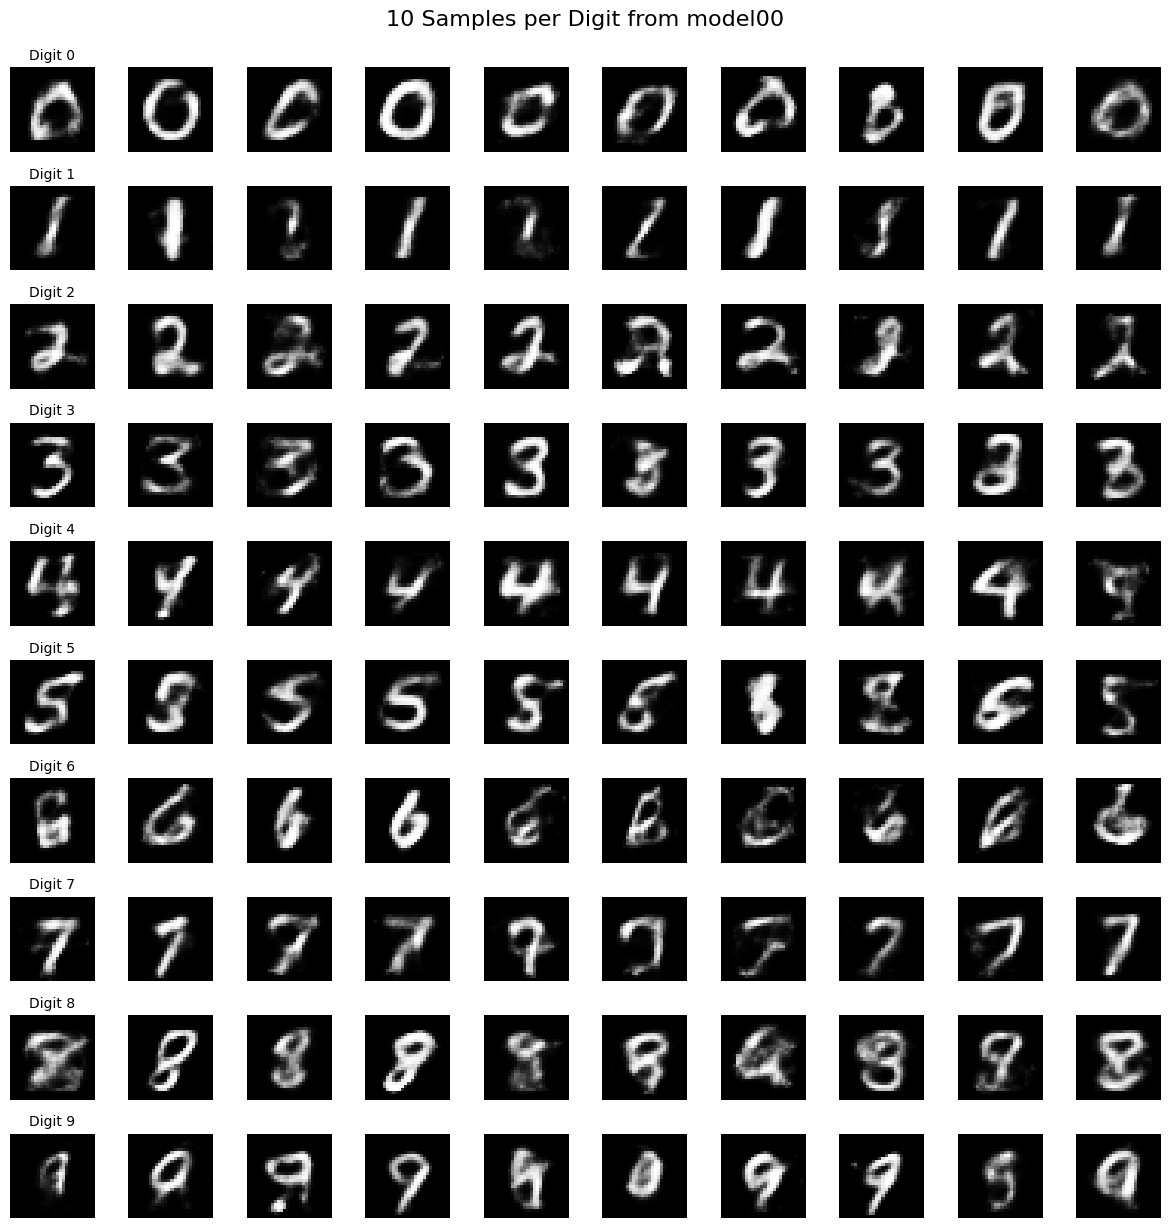

In [12]:
model=model00 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
# large sample size for training


synthetic_gen_size = 6000
# large sample size for training

gen_imgs_before_filter,y_before_filter = generate_images_in_batches(
    model=model00,
    total_samples=synthetic_gen_size,
    latent_dim=latent_dim,
    num_classes=10,
    batch_size=10000,
    device=device
)
# Load synthetic data
#synthetic = torch.load(f"data_saved/synthetic_mnist_cvae_{sample_size}_2.pt")
images = gen_imgs_before_filter # [N, 1, 28, 28]
labels = y_before_filter  # [N]

# Ensure on CPU for plotting
images = images.cpu()
labels = labels.cpu()

# Plot 10 samples for each digit
fig, axes = plt.subplots(10, 10, figsize=(12, 12))

for digit in range(10):
    digit_indices = (labels == digit).nonzero(as_tuple=True)[0]
    selected_indices = digit_indices[:10]  # take first 10

    for i, idx in enumerate(selected_indices):
        ax = axes[digit, i]
        ax.imshow(images[idx].squeeze(), cmap="gray")
        ax.axis("off")
        if i == 0:
            ax.set_title(f"Digit {digit}", fontsize=10)

plt.tight_layout()
plt.suptitle("10 Samples per Digit from model00", y=1.02, fontsize=16)
plt.show()

## Calculate loss

In [13]:
def evaluate_cvae(model, dataloader, device, num_classes=10):
    """
    Evaluate a CVAE model on a given dataloader.

    Args:
        model: The trained CVAE model.
        dataloader: PyTorch DataLoader for evaluation.
        device: torch.device('cuda') or torch.device('cpu').
        num_classes: Number of label classes (default=10).

    Returns:
        dict with average total loss, reconstruction loss (BCE), and KL divergence.
    """
    model.eval()
    total_loss = 0.0
    total_recon_loss = 0.0
    total_kl = 0.0
    num_samples = 0

    with torch.no_grad():
        for x, y in dataloader:
            x = x.view(-1, 784).to(device)
            y = F.one_hot(y, num_classes=num_classes).float().to(device)

            recon_x, mu, logvar = model(x, y)
            BCE = F.binary_cross_entropy(recon_x, x, reduction='sum')
            KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
            loss = BCE + KLD

            total_loss += loss.item()
            total_recon_loss += BCE.item()
            total_kl += KLD.item()
            num_samples += x.size(0)

    return {
        "avg_total_loss": total_loss / num_samples,
        "avg_recon_loss": total_recon_loss / num_samples,
        "avg_kl_divergence": total_kl / num_samples
    }

test_dataset = datasets.MNIST(root="./data", train=False, transform=transforms.ToTensor())
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

model0_score = evaluate_cvae(model0, test_loader, device)
model1_score = evaluate_cvae(model1, test_loader, device)
model00_score = evaluate_cvae(model00, test_loader, device)

# save the scores tp compare_result
compare_result = {
    "model0": model0_score,
    "model1": model1_score,
    "model00": model00_score
}
# Print the scores
print(f"Model 1 (original) scores: {model0_score}")
print(f"Model 2 (filtered synthetic) scores: {model1_score}")
print(f"Model 00 (unfiltered synthetic) scores: {model00_score}")


Model 1 (original) scores: {'avg_total_loss': 107.22001674804687, 'avg_recon_loss': 85.30939050292969, 'avg_kl_divergence': 21.91062607116699}
Model 2 (filtered synthetic) scores: {'avg_total_loss': 109.79841806640626, 'avg_recon_loss': 88.9507640625, 'avg_kl_divergence': 20.84765407104492}
Model 00 (unfiltered synthetic) scores: {'avg_total_loss': 107.04142314453125, 'avg_recon_loss': 85.75990952148437, 'avg_kl_divergence': 21.28151360168457}


In [14]:
model=model0
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

synthetic_gen_size = 6000
gen_imgs_before_filter,y_before_filter = generate_images_in_batches(
    model=model,
    total_samples=synthetic_gen_size,
    latent_dim=latent_dim,
    num_classes=10,
    batch_size=10000,
    device=device
)
# Load synthetic data
#synthetic = torch.load(f"data_saved/synthetic_mnist_cvae_{sample_size}_2.pt")
images = gen_imgs_before_filter # [N, 1, 28, 28]
labels = y_before_filter  # [N]

from FID import calculate_fid_score_2

transform = transforms.ToTensor()

real_ds = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
synthetic_ds = TensorDataset(images, labels)
fid_value0 = calculate_fid_score_2(real_ds, synthetic_ds)

In [15]:
model=model1
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

synthetic_gen_size = 6000
gen_imgs_before_filter,y_before_filter = generate_images_in_batches(
    model=model,
    total_samples=synthetic_gen_size,
    latent_dim=latent_dim,
    num_classes=10,
    batch_size=10000,
    device=device
)
# Load synthetic data
#synthetic = torch.load(f"data_saved/synthetic_mnist_cvae_{sample_size}_2.pt")
images = gen_imgs_before_filter # [N, 1, 28, 28]
labels = y_before_filter  # [N]

from FID import calculate_fid_score_2

transform = transforms.ToTensor()

real_ds = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
synthetic_ds = TensorDataset(images, labels)
fid_value1= calculate_fid_score_2(real_ds, synthetic_ds)

In [16]:
model=model00
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

synthetic_gen_size = 6000
gen_imgs_before_filter,y_before_filter = generate_images_in_batches(
    model=model,
    total_samples=synthetic_gen_size,
    latent_dim=latent_dim,
    num_classes=10,
    batch_size=10000,
    device=device
)
# Load synthetic data
#synthetic = torch.load(f"data_saved/synthetic_mnist_cvae_{sample_size}_2.pt")
images = gen_imgs_before_filter # [N, 1, 28, 28]
labels = y_before_filter  # [N]

from FID import calculate_fid_score_2

transform = transforms.ToTensor()

real_ds = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
synthetic_ds = TensorDataset(images, labels)
fid_value00= calculate_fid_score_2(real_ds, synthetic_ds)

In [17]:
fid_value0, fid_value1, fid_value00

(144.00169372558594, 138.3333740234375, 175.89352416992188)

In [18]:
import numpy as np
import torch
from torch.utils.data import DataLoader
from torchvision.transforms.functional import resize
from torchvision.models.inception import inception_v3
from sklearn.neighbors import NearestNeighbors

@torch.no_grad()
def extract_inception_features(dataset, batch_size=256, device=None):
    """
    Extract 2048-D features from the Inception-v3 pool3 layer.
    Returns a numpy array of shape (N, 2048) with float32 dtype.
    """
    device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = inception_v3(pretrained=True, transform_input=False).to(device)
    model.fc = torch.nn.Identity()  # remove classification head
    model.eval()

    feats = []
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    for batch in loader:
        imgs = batch[0] if isinstance(batch, (list, tuple)) else batch
        if imgs.dim() == 3:
            imgs = imgs.unsqueeze(0)
        if imgs.shape[1] == 1:  # grayscale -> RGB
            imgs = imgs.repeat(1, 3, 1, 1)
        imgs = resize(imgs, [299, 299], antialias=True).to(device, dtype=torch.float32)
        if imgs.max() <= 1:
            imgs = imgs * 255.0
        feats.append(model(imgs).cpu())
    feats = torch.cat(feats, dim=0).numpy().astype(np.float32)
    return feats


def _knn_radius(features, k):
    """
    For each point in a set, compute the distance to its k-th nearest neighbor
    within the same set (excluding itself). This distance is called the "radius"
    and defines the local neighborhood size for that point.
    Returns:
        radii: (N,) array of distances to the k-th NN
        nbrs: fitted NearestNeighbors object
    """
    N = features.shape[0]
    k_eff = min(k, max(1, N - 1))
    # Use k_eff + 1 because the closest neighbor is the point itself (distance 0)
    nbrs = NearestNeighbors(n_neighbors=k_eff + 1, algorithm='auto').fit(features)
    dists, idxs = nbrs.kneighbors(features)
    # Remove the self-distance (first column)
    dists_wo_self = dists[:, 1:]
    radii = dists_wo_self[:, -1]  # distance to the k-th NN (after removing self)
    return radii, nbrs


def compute_precision_recall(real_feats, gen_feats, k=5):
    """
    Compute precision, recall, and coverage as in:
    Kynkäänniemi et al., "Improved Precision and Recall Metric for Assessing 
    Generative Models" (ICLR 2019).
    
    Precision: fraction of generated samples that lie within the "real data manifold"
    Recall:    fraction of real samples that lie within the "generated data manifold"
    Coverage:  here, same definition as recall (can be defined differently if needed)
    """
    real_feats = np.asarray(real_feats, dtype=np.float32)
    gen_feats  = np.asarray(gen_feats,  dtype=np.float32)

    # Radii within each set
    radii_real, nbrs_real = _knn_radius(real_feats, k)
    radii_gen,  nbrs_gen  = _knn_radius(gen_feats,  k)

    # Precision: For each generated sample, find the nearest real sample.
    # If the distance is <= that real sample's radius, count as "in real manifold".
    distances_rg, indices_rg = nbrs_real.kneighbors(gen_feats, n_neighbors=1)
    precision = float(np.mean(distances_rg[:, 0] <= radii_real[indices_rg[:, 0]]))

    # Recall: For each real sample, find the nearest generated sample.
    # If the distance is <= that generated sample's radius, count as "in generated manifold".
    distances_gr, indices_gr = nbrs_gen.kneighbors(real_feats, n_neighbors=1)
    recall = float(np.mean(distances_gr[:, 0] <= radii_gen[indices_gr[:, 0]]))

    # Coverage: Here we define it the same as recall.
    coverage = recall
    return precision, recall, coverage

@torch.no_grad()
def calculate_prd_scores(real_ds, synth_ds, batch_size=256, k=5):
    """
    Full pipeline: extract features for real and synthetic datasets,
    then compute precision, recall, and coverage.
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    real_feats = extract_inception_features(real_ds, batch_size=batch_size, device=device)
    gen_feats  = extract_inception_features(synth_ds, batch_size=batch_size, device=device)
    return compute_precision_recall(real_feats, gen_feats, k=k)


In [23]:
model=model1
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

synthetic_gen_size = 6000
gen_imgs_before_filter,y_before_filter = generate_images_in_batches(
    model=model,
    total_samples=synthetic_gen_size,
    latent_dim=latent_dim,
    num_classes=10,
    batch_size=10000,
    device=device
)
# Load synthetic data
#synthetic = torch.load(f"data_saved/synthetic_mnist_cvae_{sample_size}_2.pt")
images = gen_imgs_before_filter # [N, 1, 28, 28]
labels = y_before_filter  # [N]

from FID import calculate_fid_score_2

transform = transforms.ToTensor()

real_ds = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
synthetic_ds = TensorDataset(images, labels)
precision, recall, coverage = calculate_prd_scores(real_ds, synthetic_ds, batch_size=256, k=5)
print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, Coverage: {coverage:.4f}")

/home/qiyuanliu/.conda/envs/vae_env/lib/python3.8/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/qiyuanliu/.conda/envs/vae_env/lib/python3.8/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Precision: 0.4288, Recall: 0.2548, Coverage: 0.2548


In [24]:
model=model0
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

synthetic_gen_size = 6000
gen_imgs_before_filter,y_before_filter = generate_images_in_batches(
    model=model,
    total_samples=synthetic_gen_size,
    latent_dim=latent_dim,
    num_classes=10,
    batch_size=10000,
    device=device
)
# Load synthetic data
#synthetic = torch.load(f"data_saved/synthetic_mnist_cvae_{sample_size}_2.pt")
images = gen_imgs_before_filter # [N, 1, 28, 28]
labels = y_before_filter  # [N]

from FID import calculate_fid_score_2

transform = transforms.ToTensor()

real_ds = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
synthetic_ds = TensorDataset(images, labels)
precision, recall, coverage = calculate_prd_scores(real_ds, synthetic_ds, batch_size=256, k=5)
print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, Coverage: {coverage:.4f}")

/home/qiyuanliu/.conda/envs/vae_env/lib/python3.8/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/qiyuanliu/.conda/envs/vae_env/lib/python3.8/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Precision: 0.2843, Recall: 0.4767, Coverage: 0.4767


In [25]:
model=model00
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

synthetic_gen_size = 6000
gen_imgs_before_filter,y_before_filter = generate_images_in_batches(
    model=model,
    total_samples=synthetic_gen_size,
    latent_dim=latent_dim,
    num_classes=10,
    batch_size=10000,
    device=device
)
# Load synthetic data
#synthetic = torch.load(f"data_saved/synthetic_mnist_cvae_{sample_size}_2.pt")
images = gen_imgs_before_filter # [N, 1, 28, 28]
labels = y_before_filter  # [N]

from FID import calculate_fid_score_2

transform = transforms.ToTensor()

real_ds = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
synthetic_ds = TensorDataset(images, labels)
precision, recall, coverage = calculate_prd_scores(real_ds, synthetic_ds, batch_size=256, k=5)
print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, Coverage: {coverage:.4f}")

/home/qiyuanliu/.conda/envs/vae_env/lib/python3.8/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/qiyuanliu/.conda/envs/vae_env/lib/python3.8/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Precision: 0.1650, Recall: 0.1915, Coverage: 0.1915
